<a href="https://colab.research.google.com/github/mhashamhussain2001/MATH-CSCI485_MuhammadHasham_Hussain/blob/main/Assignment_3/Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATH/CSCI 485 — Assignment 3: Image Compression via Block-wise SVD

**Objective:** Explore Singular Value Decomposition (SVD) for compressing grayscale images.  
We partition an image into non-overlapping 8×8 blocks, retain only the top-*k* singular values per block, and analyze image quality and compression ratio for *k* ∈ {1, 2, …, 8}.

---

## 1. Imports & Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os
import math

# Reproducibility
np.random.seed(42)

# Output directory
os.makedirs('output', exist_ok=True)

---
## 2. Preprocessing — Load & Prepare the Image

We load the source image from URL, convert to grayscale, and resize to **512×512** pixels (ensuring both are divisible by 8)

Image shape : (512, 512)  (H x W)
Value range : [0, 255]


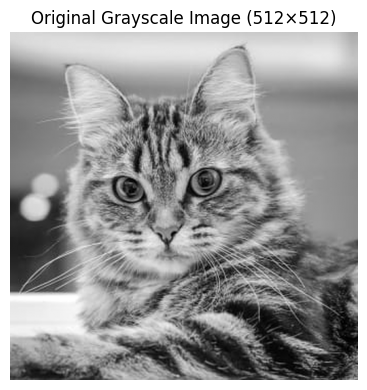

In [20]:
import requests
from io import BytesIO

IMAGE_URL = 'https://d2zp5xs5cp8zlg.cloudfront.net/image-79322-340.jpg'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(IMAGE_URL, headers=headers, timeout=15)
img_pil = Image.open(BytesIO(response.content)).convert('L')   # to grayscale

# Resize to 512×512
img_pil = img_pil.resize((512, 512), Image.LANCZOS)

# Convert to float64 array in [0, 255]
img = np.array(img_pil, dtype=np.float64)

print(f'Image shape : {img.shape}  (H x W)')
print(f'Value range : [{img.min():.0f}, {img.max():.0f}]')

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Grayscale Image (512×512)')
plt.axis('off')
plt.tight_layout()
plt.savefig('output/original.png', dpi=150)
plt.show()

---
## 3. Block-wise SVD Core Functions

### 3.1  `compress_block(block, k)`

Given an *m × n* block and a rank *k*, the function:
1. Computes the full SVD: **A = U Σ Vᵀ**
2. Keeps only the top-*k* singular triplets.
3. Returns the rank-*k* approximation **Â = U[:, :k] · diag(Σ[:k]) · Vᵀ[:k, :]**

Pixel values are clipped to [0, 255] after reconstruction to stay in a valid range.

In [13]:
def compress_block(block: np.ndarray, k: int) -> np.ndarray:
    """
    Reconstruct `block` using its top-k singular values.

    Parameters
    ----------
    block : np.ndarray, shape (m, n)
    k     : int  — number of singular values to retain (1 ≤ k ≤ min(m, n))

    Returns
    -------
    np.ndarray, shape (m, n)  — rank-k reconstruction, clipped to [0, 255]
    """
    U, s, Vt = np.linalg.svd(block, full_matrices=True)
    # Truncate to rank k
    U_k  = U[:, :k]          # (m, k)
    s_k  = s[:k]              # (k,)
    Vt_k = Vt[:k, :]          # (k, n)
    reconstructed = U_k @ np.diag(s_k) @ Vt_k
    return np.clip(reconstructed, 0, 255)


def compress_image(img: np.ndarray, k: int, block_size: int = 8) -> np.ndarray:
    """
    Apply block-wise SVD compression to a full image.

    Parameters
    ----------
    img        : np.ndarray, shape (H, W) — grayscale image
    k          : int — singular values per block
    block_size : int — side length of each square block (default 8)

    Returns
    -------
    np.ndarray, shape (H, W) — reconstructed image
    """
    H, W = img.shape
    output = np.zeros_like(img)

    for r in range(0, H, block_size):
        for c in range(0, W, block_size):
            block = img[r:r + block_size, c:c + block_size]
            output[r:r + block_size, c:c + block_size] = compress_block(block, k)

    return output

### 3.2  Compression Ratio & Error Metrics

For an **8×8** block:
- **Original values:** 64
- **Stored values at rank *k*:** *k*(8 + 8 + 1) = 17*k*   (columns of U, entries of Σ, rows of Vᵀ)

$$\text{Compression Ratio} = \frac{64}{17k}$$

We also compute:
- **Frobenius norm error** — total pixel-level difference between original and reconstructed image.
- **PSNR (dB)** — perceptual quality metric; higher is better (>30 dB is usually acceptable).

In [14]:
def compression_ratio(k: int, block_size: int = 8) -> float:
    """Ratio of original block data to stored SVD data."""
    original  = block_size * block_size                # e.g. 64
    retained  = k * (block_size + block_size + 1)      # k * (m + n + 1)
    return original / retained


def frobenius_error(original: np.ndarray, reconstructed: np.ndarray) -> float:
    """Normalised Frobenius norm error."""
    return np.linalg.norm(original - reconstructed, 'fro')


def psnr(original: np.ndarray, reconstructed: np.ndarray, max_val: float = 255.0) -> float:
    """Peak Signal-to-Noise Ratio in dB."""
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val / math.sqrt(mse))


---
## 4. Compression Analysis — *k* ∈ {1, …, 8}

We sweep *k* from 1 to 8, compress the image, and record the compression ratio, Frobenius error, and PSNR.

In [15]:
K_VALUES    = list(range(1, 9))   # k = 1, 2, …, 8
BLOCK_SIZE  = 8

results = {}

for k in K_VALUES:
    compressed = compress_image(img, k, block_size=BLOCK_SIZE)
    ratio      = compression_ratio(k, block_size=BLOCK_SIZE)
    frob_err   = frobenius_error(img, compressed)
    psnr_val   = psnr(img, compressed)

    results[k] = {
        'image'        : compressed,
        'ratio'        : ratio,
        'frob_error'   : frob_err,
        'psnr'         : psnr_val,
    }

    # Save compressed image
    out_img = Image.fromarray(compressed.astype(np.uint8))
    out_img.save(f'output/compressed_k{k}.png')

    print(f'k={k:2d} | Ratio={ratio:.4f} | Frob Error={frob_err:8.1f} | PSNR={psnr_val:.2f} dB')

k= 1 | Ratio=3.7647 | Frob Error=  5156.9 | PSNR=28.07 dB
k= 2 | Ratio=1.8824 | Frob Error=  2523.8 | PSNR=34.28 dB
k= 3 | Ratio=1.2549 | Frob Error=  1007.6 | PSNR=42.25 dB
k= 4 | Ratio=0.9412 | Frob Error=   352.9 | PSNR=51.36 dB
k= 5 | Ratio=0.7529 | Frob Error=    80.5 | PSNR=64.19 dB
k= 6 | Ratio=0.6275 | Frob Error=    27.1 | PSNR=73.66 dB
k= 7 | Ratio=0.5378 | Frob Error=     9.0 | PSNR=83.19 dB
k= 8 | Ratio=0.4706 | Frob Error=     0.0 | PSNR=296.47 dB


---
## 5. Visualization

### 5.1  Compression Ratio & Frobenius Error vs. *k*

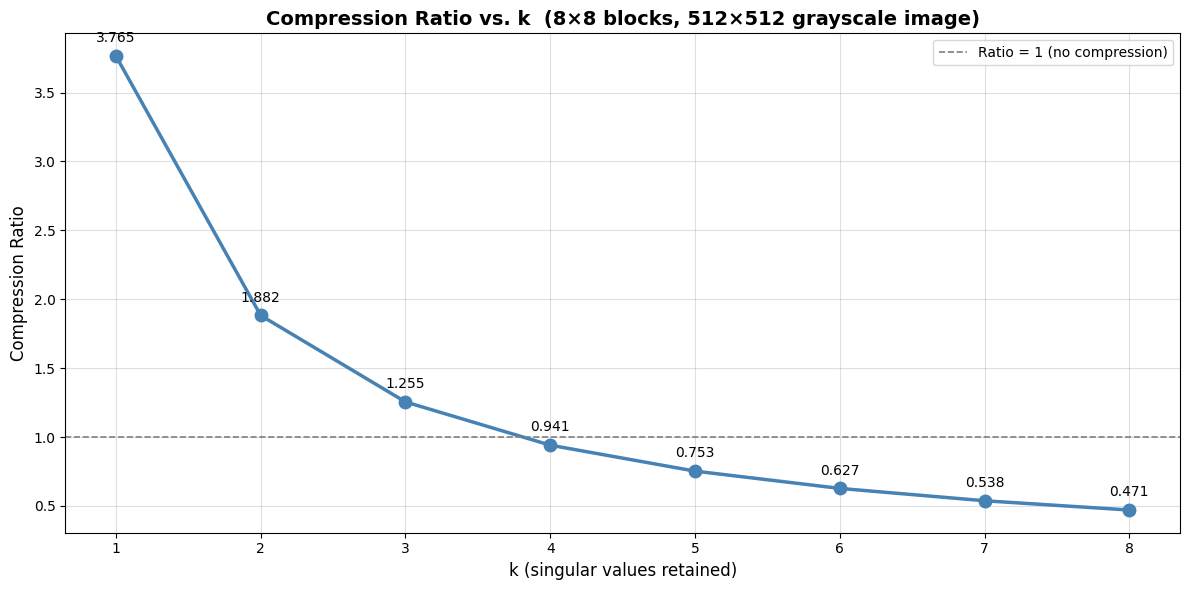

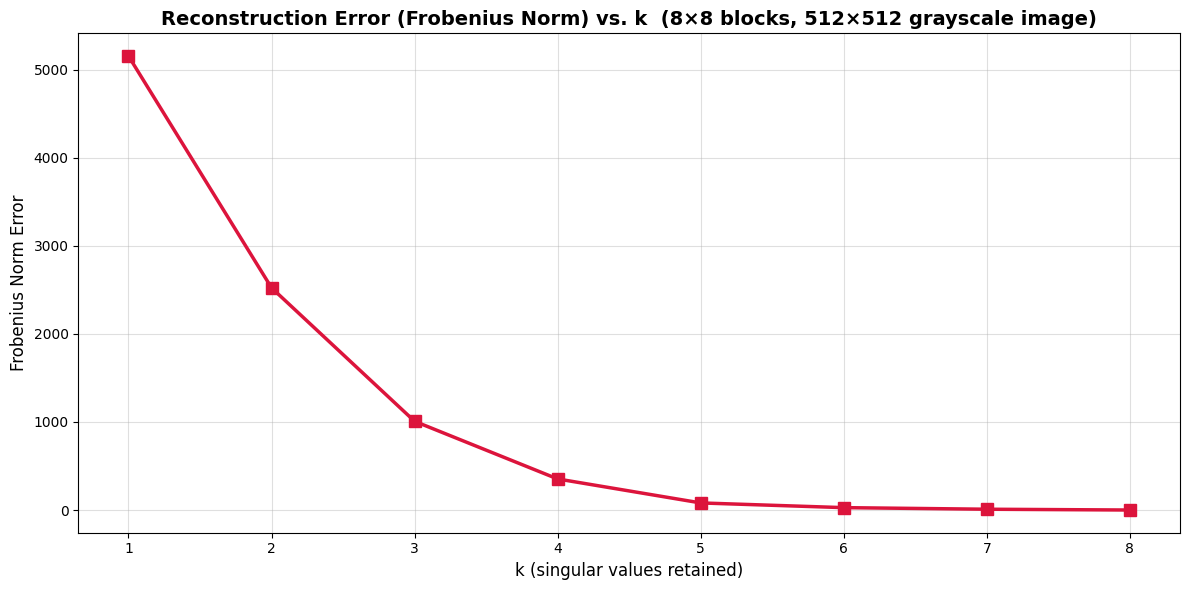

In [16]:
k_vals   = K_VALUES
ratios   = [results[k]['ratio']      for k in k_vals]
errors   = [results[k]['frob_error'] for k in k_vals]
psnr_vals= [results[k]['psnr']       for k in k_vals]

# ── Plot 1: Compression Ratio  (saved at 1200×600 px to match Word doc) ───────
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
ax.plot(k_vals, ratios, 'o-', color='steelblue', lw=2.5, ms=9)
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='Ratio = 1 (no compression)')
for x, y in zip(k_vals, ratios):
    ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('Compression Ratio vs. k  (8×8 blocks, 512×512 grayscale image)', fontsize=14, fontweight='bold')
ax.set_xlabel('k (singular values retained)', fontsize=12)
ax.set_ylabel('Compression Ratio', fontsize=12)
ax.set_xticks(k_vals); ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/plot_ratio.png', dpi=100)   # 1200×600 px
plt.show()

# ── Plot 2: Frobenius Error  (saved at 1200×600 px to match Word doc) ─────────
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
ax.plot(k_vals, errors, 's-', color='crimson', lw=2.5, ms=9)
ax.set_title('Reconstruction Error (Frobenius Norm) vs. k  (8×8 blocks, 512×512 grayscale image)', fontsize=14, fontweight='bold')
ax.set_xlabel('k (singular values retained)', fontsize=12)
ax.set_ylabel('Frobenius Norm Error', fontsize=12)
ax.set_xticks(k_vals); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/plot_error.png', dpi=100)   # 1200×600 px
plt.show()

### 5.2  Visual Quality Comparison Across *k*

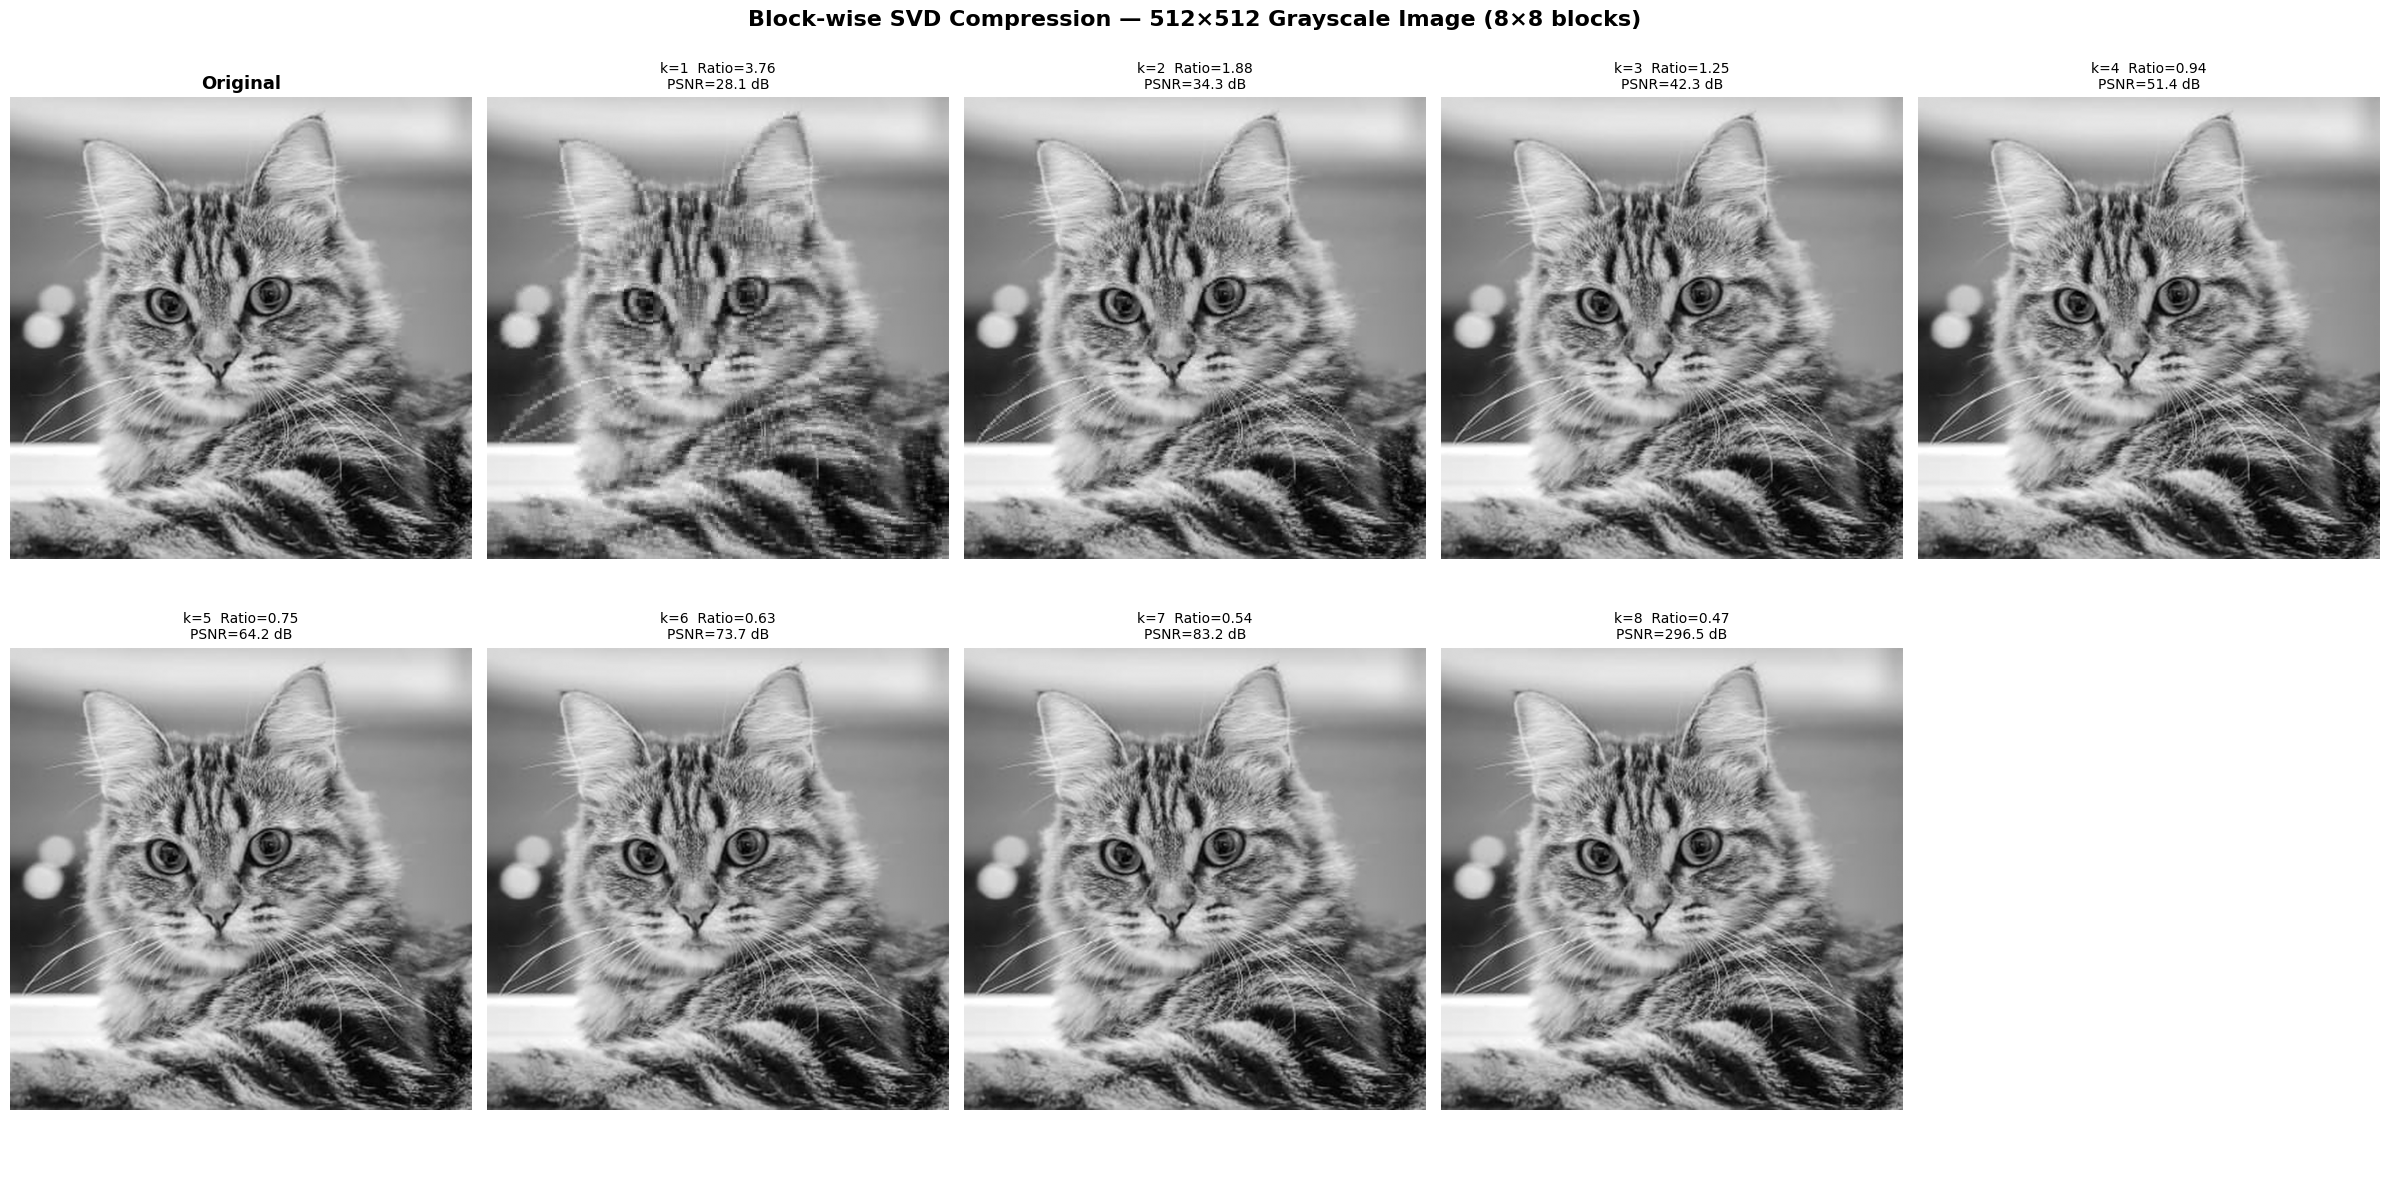

In [17]:
# ── Plot 3: Visual grid  (saved at 2400×1200 px to match Word doc) ───────────
fig = plt.figure(figsize=(24, 12), dpi=100)
axes = fig.subplots(2, 5)

# Original
axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# k = 1..8
positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3)]
for i, k in enumerate(K_VALUES):
    r, c = positions[i]
    axes[r, c].imshow(results[k]['image'], cmap='gray', vmin=0, vmax=255)
    axes[r, c].set_title(
        f'k={k}  Ratio={results[k]["ratio"]:.2f}\nPSNR={results[k]["psnr"]:.1f} dB',
        fontsize=10)
    axes[r, c].axis('off')

axes[1, 4].axis('off')

fig.suptitle('Block-wise SVD Compression — 512×512 Grayscale Image (8×8 blocks)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output/plot_grid.png', dpi=100)   # 2400×1200 px
plt.show()

---
## 6. Summary Table

In [18]:
import pandas as pd

summary = pd.DataFrame({
    'k'                 : K_VALUES,
    'Stored Values/Block': [k * (BLOCK_SIZE + BLOCK_SIZE + 1) for k in K_VALUES],
    'Compression Ratio' : [round(results[k]['ratio'], 4) for k in K_VALUES],
    'Frob. Error'       : [round(results[k]['frob_error'], 2) for k in K_VALUES],
    'PSNR (dB)'         : [round(results[k]['psnr'], 2) for k in K_VALUES],
})
summary.set_index('k', inplace=True)
print(summary.to_string())

   Stored Values/Block  Compression Ratio  Frob. Error  PSNR (dB)
k                                                                
1                   17             3.7647      5156.89      28.07
2                   34             1.8824      2523.82      34.28
3                   51             1.2549      1007.65      42.25
4                   68             0.9412       352.91      51.36
5                   85             0.7529        80.55      64.19
6                  102             0.6275        27.09      73.66
7                  119             0.5378         9.04      83.19
8                  136             0.4706         0.00     296.47


---
## 7. [Optional] Experiment with Other Block Sizes

We repeat the sweep for block sizes **4×4** and **16×16** to observe the trade-off between compression ratio and reconstruction quality.

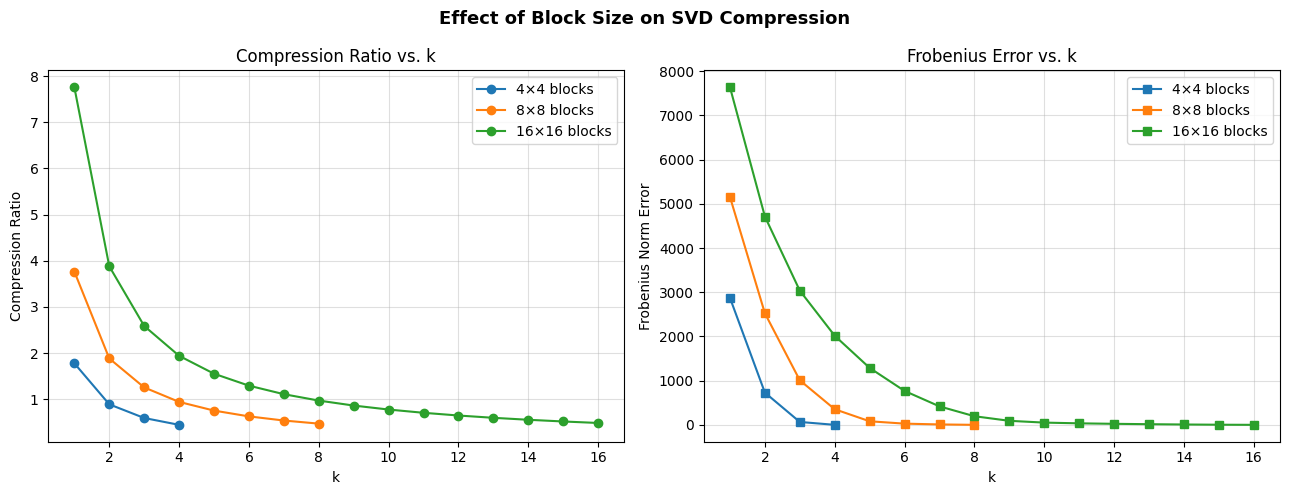

In [19]:
BLOCK_SIZES_EXP = [4, 8, 16]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for bs in BLOCK_SIZES_EXP:
    max_k = bs   # max rank = min(bs, bs)
    k_range = list(range(1, max_k + 1))

    ratios_bs = []
    errors_bs = []

    for k in k_range:
        compressed = compress_image(img, k, block_size=bs)
        ratios_bs.append(compression_ratio(k, block_size=bs))
        errors_bs.append(frobenius_error(img, compressed))

    axes[0].plot(k_range, ratios_bs, 'o-', label=f'{bs}×{bs} blocks')
    axes[1].plot(k_range, errors_bs, 's-', label=f'{bs}×{bs} blocks')

axes[0].set_title('Compression Ratio vs. k', fontsize=12)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Compression Ratio')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].set_title('Frobenius Error vs. k', fontsize=12)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Frobenius Norm Error')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Effect of Block Size on SVD Compression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/block_size_comparison.png', dpi=150)
plt.show()